# scikit-learn Bootcamp — W1, Day 13
```
##### Imbalanced Classes
##### class_weight · SMOTE · imblearn · precision-recall trade-off · threshold tuning
##### Q1 — EDA: visualise class imbalance and its effect on naive models
##### Q2 — class_weight='balanced': before and after comparison
##### Q3 — SMOTE oversampling: resample and re-evaluate
##### Q4 — Threshold tuning: optimise F1, precision, recall per business goal
##### Q5 — Strategy comparison: accuracy, F1-macro, AUC across all approaches
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, f1_score, precision_score, recall_score,
    precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
np.random.seed(420)

In [2]:
# Dataset — MedPulse Rare Adverse Event Detection (severe imbalance ~3%)
np.random.seed(420)
n = 8000
age               = np.random.normal(52, 14, n).clip(18, 85).astype(int)
session_depth     = np.random.poisson(3, n).clip(1, 20)
time_on_site      = np.random.lognormal(1.5, 0.7, n).clip(0.5, 60)
drug_searches     = np.random.poisson(1.2, n).clip(0, 10)
symptom_count     = np.random.poisson(2.0, n).clip(0, 15)
is_mobile         = np.random.binomial(1, 0.55, n)
has_chronic       = np.random.binomial(1, 0.35, n)

log_odds = (-4.5 + 0.025*age + 0.08*symptom_count + 0.12*drug_searches
            + 0.5*has_chronic + 0.06*session_depth + np.random.normal(0, 0.4, n))
prob = 1/(1+np.exp(-log_odds))
adverse_event = np.random.binomial(1, prob)

df = pd.DataFrame({
    'age': age, 'session_depth': session_depth, 'time_on_site': time_on_site.round(2),
    'drug_searches': drug_searches, 'symptom_count': symptom_count,
    'is_mobile': is_mobile, 'has_chronic': has_chronic, 'adverse_event': adverse_event
})
print('Shape:', df.shape)
print('Adverse event rate:', df['adverse_event'].mean().round(4))
display(df.head())

Shape: (8000, 8)
Adverse event rate: 0.0804


,age,session_depth,time_on_site,drug_searches,symptom_count,is_mobile,has_chronic,adverse_event
0,45,1,23.20,0,1,1,0,0
1,25,1,5.30,2,5,1,1,0
2,44,3,1.02,1,1,1,0,0
3,47,3,5.57,1,3,1,0,0
4,56,2,3.55,2,2,0,0,0


---
### Q1 — EDA: visualise class imbalance
```
# (a) Bar chart of class distribution. Label % for each class.
# (b) Train a naive LogisticRegression with no imbalance handling.
#     Print classification report. What does accuracy tell you? What does it hide?
# (c) Confusion matrix for naive model — visualise as heatmap.
# (d) Plot feature distributions for adverse_event=0 vs 1 (5 features, KDE overlay).
```

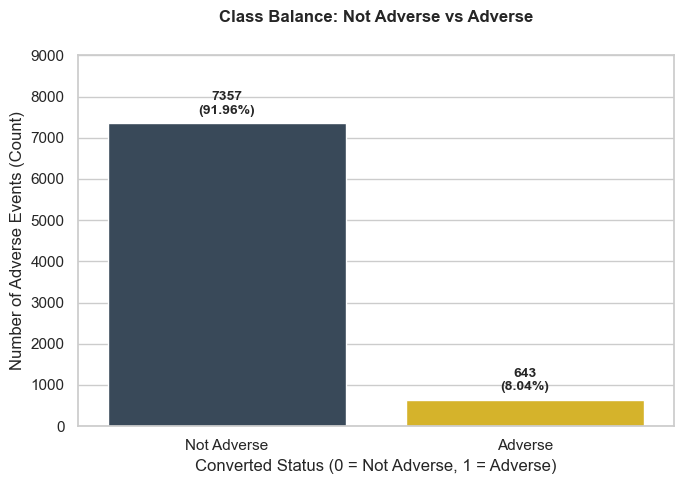

In [62]:
# (a) Bar chart of class distribution. Label % for each class.

plt.figure(figsize=(7, 5))

# Use countplot to display the explicit distribution of records
# We assign individual colors to the class categories
ax = sns.countplot(
    data=df,
    x='adverse_event',
    palette={'0': '#34495e', '1': '#f1c40f'}
)

# Added Loop to Label % for each class
total_samples = len(df)
for bar in ax.patches:
    count = int(bar.get_height())
    percentage = (count / total_samples) * 100
    
    # Label text showing both raw count and percentage
    label_text = f"{count}\n({percentage:.2f}%)"
    
    # Position text slightly above the top center of each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + 150,  # Offset so text doesn't overlap the top of the bar
        label_text,
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Final aesthetic treatments
plt.title('Class Balance: Not Adverse vs Adverse', fontsize=12, fontweight='bold', pad=24)
plt.xlabel('Converted Status (0 = Not Adverse, 1 = Adverse)')
plt.ylabel('Number of Adverse Events (Count)')
plt.ylim(0,9000)
plt.xticks([0, 1], ['Not Adverse', 'Adverse'])
plt.tight_layout()
plt.show()

In [ ]:
# (b) Train a naive LogisticRegression with no imbalance handling.
#     Print classification report. 

feature_cols=['age', 'session_depth', 'time_on_site', 'drug_searches', 'symptom_count', 'is_mobile', 'has_chronic']
X=df[feature_cols] 
y=df['adverse_event']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=420,stratify=y)

print(f'Shape: {df.shape} | Conversion: {y.mean():.2%}')

lr_model = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=420))])

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, target_names=['No Event (0)', 'Adverse Event (1)']))
print(f'Train accuracy: {lr_model.score(X_train, y_train):.4f}')
print(f'Test  accuracy: {lr_model.score(X_test,  y_test):.4f}')

Shape: (8000, 8) | Conversion: 8.04%

Classification Report (Test Set):
                   precision    recall  f1-score   support

     No Event (0)       0.92      1.00      0.96      1471
Adverse Event (1)       0.00      0.00      0.00       129

         accuracy                           0.92      1600
        macro avg       0.46      0.50      0.48      1600
     weighted avg       0.85      0.92      0.88      1600

Train accuracy: 0.9197
Test  accuracy: 0.9194


```
# What does accuracy tell you? 
Accuracy only tells you the overall proportion of correct predictions. Because 92% of patients have no adverse events, a dummy model guessing "0" for everyone automatically achieves 92% accuracy. This high score simply reflects the dataset's baseline class distribution.

# What does it hide?
Accuracy hides complete failure on the minority class. Because of the severe imbalance, the model can safely ignore rare adverse events to keep overall error low. The classification report will show a near-zero Recall and F1-score, hiding that the model completely fails to catch the rare medical risks it was designed to detect.

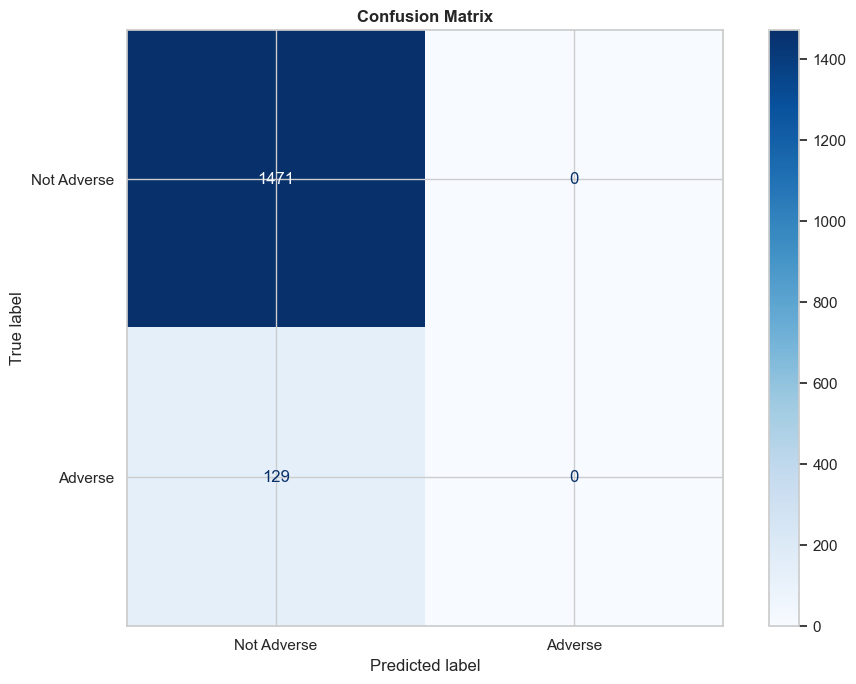

In [ ]:
# (c) Confusion matrix for naive model — visualise as heatmap.

# Compute raw confusion metrics matrices
cm = confusion_matrix(y_test, y_pred)

# Plotting
plt.figure(figsize=(10, 7))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Adverse','Adverse'])
disp.plot(cmap='Blues', ax=plt.gca(), values_format='d')

plt.title('Confusion Matrix', fontweight='bold') # Pass ax into the .plot() function to force it onto our custom-sized canvas

plt.tight_layout()
plt.show()

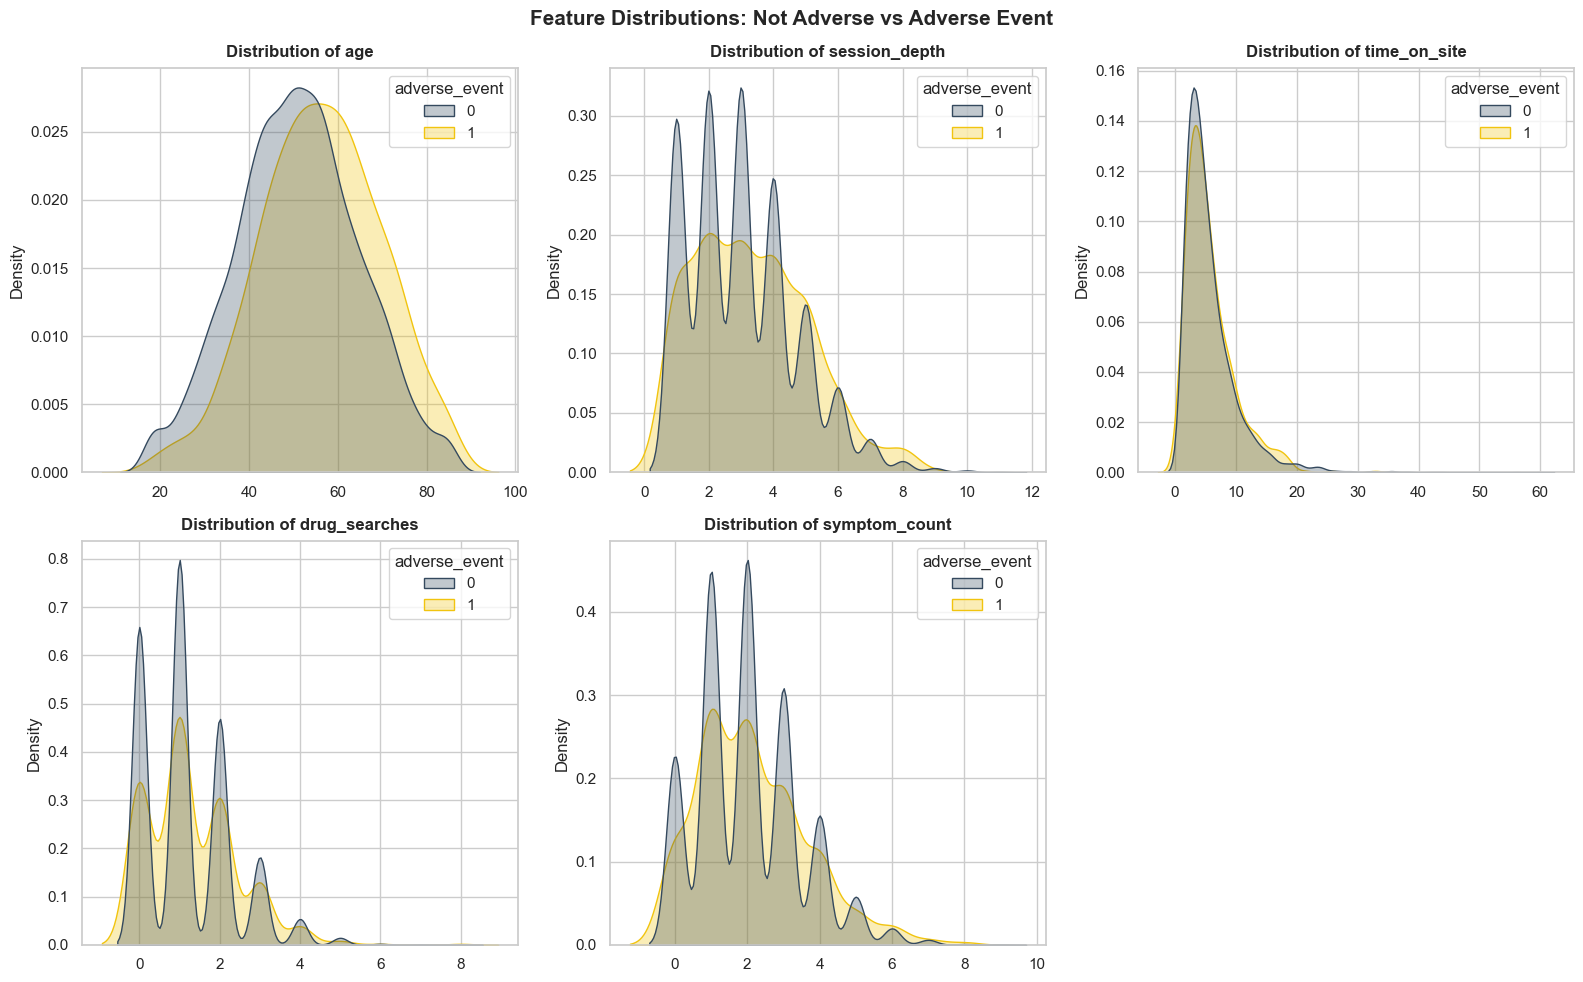

In [23]:
# (d) Plot feature distributions for adverse_event=0 vs 1 (5 features, KDE overlay).

continuous_features = ['age', 'session_depth', 'time_on_site', 'drug_searches', 'symptom_count']

# Set up a clean 2x3 grid canvas to fit all 5 features comfortably
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()  # Flatten the 2D grid into a 1D array for easier looping

# Define matching colors to stay consistent with your earlier distribution plot
class_colors = {0: '#34495e', 1: '#f1c40f'}

for i, feature in enumerate(continuous_features):
    # Plot overlapping KDE curves for each target class
    sns.kdeplot(
        data=df,
        x=feature,
        hue='adverse_event',
        palette=class_colors,
        fill=True,
        alpha=0.3,
        common_norm=False,  # Essential for imbalanced data so curves scale independently
        ax=axes[i]
    )
    
    # Clean up titles and axis labels for scannability
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold', pad=8)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

# Delete the 6th unused subplot axis to keep the layout looking professional
fig.delaxes(axes[5])

plt.suptitle('Feature Distributions: Not Adverse vs Adverse Event', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()

---
### Q2 — class_weight='balanced'
```
# (a) Fit LogisticRegression with class_weight='balanced'. Print report.
#     Compare recall for the minority class vs naive model.
# (b) Fit RandomForest with class_weight='balanced'. Print report.
# (c) Plot confusion matrices for all 3 models side by side.
# (d) Print AUC for all 3 — does class_weight affect AUC? Why or why not?
```

In [26]:
# (a) Fit LogisticRegression with class_weight='balanced'. Print report.
#     Compare recall for the minority class vs naive model.

lr_model_balanced = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=420, class_weight='balanced'))])

lr_model_balanced.fit(X_train, y_train)

y_pred_balanced = lr_model_balanced.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_balanced, target_names=['No Event (0)', 'Adverse Event (1)']))

# Calculate recall specifically for class 1
minority_recall_naive = recall_score(y_test, y_pred, pos_label=1)
minority_recall_balanced = recall_score(y_test, y_pred_balanced, pos_label=1)

print(f"Compare Minority Class Recall: Naive {minority_recall_naive:.4f} vs Balanced {minority_recall_balanced:.4f}")


Classification Report (Test Set):


                   precision    recall  f1-score   support

     No Event (0)       0.95      0.63      0.76      1471
Adverse Event (1)       0.12      0.60      0.20       129

         accuracy                           0.63      1600
        macro avg       0.54      0.61      0.48      1600
     weighted avg       0.88      0.63      0.71      1600

Compare Minority Class Recall: Naive 0.0000 vs Balanced 0.5969


In [31]:
# (b) Fit RandomForest with class_weight='balanced'. Print report.

rf_model_balanced = Pipeline([('scaler', StandardScaler()), ('model', 
RandomForestClassifier(n_estimators=200, max_depth=5, random_state=420, n_jobs=-1, class_weight='balanced'))])

rf_model_balanced.fit(X_train, y_train)

y_pred_balanced_rf = rf_model_balanced.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_balanced_rf, target_names=['No Event (0)', 'Adverse Event (1)']))


Classification Report (Test Set):
                   precision    recall  f1-score   support

     No Event (0)       0.93      0.70      0.80      1471
Adverse Event (1)       0.11      0.43      0.18       129

         accuracy                           0.68      1600
        macro avg       0.52      0.57      0.49      1600
     weighted avg       0.87      0.68      0.75      1600



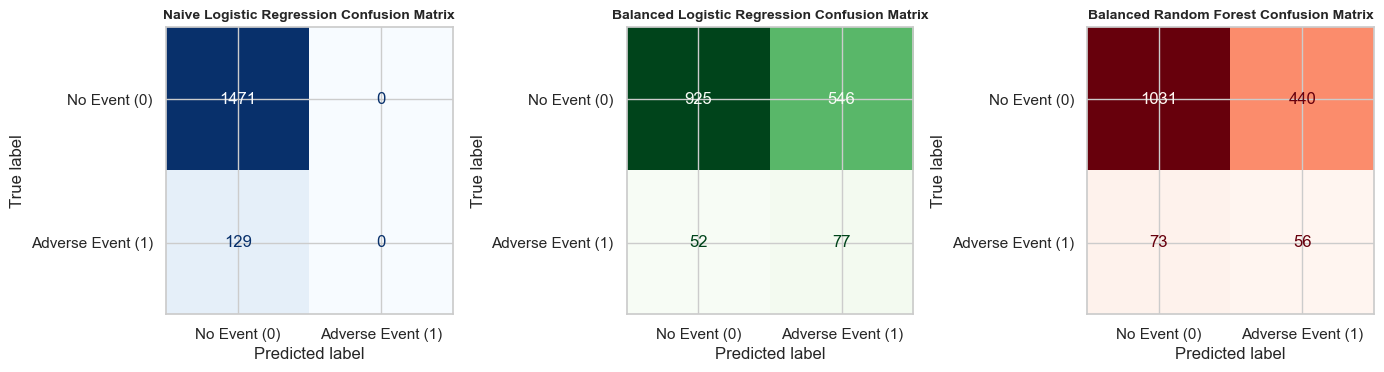

In [33]:
# (c) Plot confusion matrices for all 3 models side by side.

# Compute raw confusion metrics matrices
cm_lr_naive    = confusion_matrix(y_test, y_pred)
cm_lr_balanced = confusion_matrix(y_test, y_pred_balanced)
cm_rf_balanced = confusion_matrix(y_test, y_pred_balanced_rf)

# 4. Set up the side-by-side canvas structure
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

# --- Left Chart: Naive Logistice Regression ---
disp_lr_naive = ConfusionMatrixDisplay(confusion_matrix=cm_lr_naive, display_labels=['No Event (0)', 'Adverse Event (1)'])
disp_lr_naive.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Naive Logistic Regression Confusion Matrix', fontweight='bold', fontsize=10)

# --- Middle Chart: Balanced Logistice Regression ---
disp_lr_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_lr_balanced, display_labels=['No Event (0)', 'Adverse Event (1)'])
disp_lr_balanced.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Balanced Logistic Regression Confusion Matrix', fontweight='bold', fontsize=10)

# --- Right Chart: Balanced Random Forest ---
disp_rf_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_rf_balanced, display_labels=['No Event (0)', 'Adverse Event (1)'])
disp_rf_balanced.plot(ax=axes[2], cmap='Reds', colorbar=False)
axes[2].set_title('Balanced Random Forest Confusion Matrix', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# (d) Print AUC for all 3 

from sklearn.metrics import roc_auc_score

# 1. Generate prediction probabilities for the positive class (column index 1)
y_proba_naive    = lr_model.predict_proba(X_test)[:, 1]
y_proba_balanced = lr_model_balanced.predict_proba(X_test)[:, 1]
y_proba_rf       = rf_model_balanced.predict_proba(X_test)[:, 1]

# 2. Calculate AUC scores
auc_naive    = roc_auc_score(y_test, y_proba_naive)
auc_balanced = roc_auc_score(y_test, y_proba_balanced)
auc_rf       = roc_auc_score(y_test, y_proba_rf)

# 3. Print the results cleanly
print("=== Final Test Set ROC-AUC Scores ===")
print(f"Naive Logistic Regression:   {auc_naive:.4f}")
print(f"Balanced Logistic Regression:{auc_balanced:.4f}")
print(f"Balanced Random Forest:      {auc_rf:.4f}")

=== Final Test Set ROC-AUC Scores ===
Naive Logistic Regression:   0.6501
Balanced Logistic Regression:0.6498
Balanced Random Forest:      0.6402


```
# Does class_weight affect AUC? Why or why not?

No, changing class_weight does not significantly affect the ROC-AUC score and here is why:

Measures Ranking, Not Cutoffs: ROC-AUC evaluates how well a model ranks relative risk across all possible thresholds, measuring if a positive case scores higher than a negative case.

Weights Only Shift Bias: Applying class_weight='balanced' changes the decision boundary (altering hard 0/1 cuts like precision and recall), but it does not change the relative ordering of the raw probability scores.

Identical Separation Power: Because the fundamental ability to separate and rank the two classes remains unchanged, the total Area Under the Curve (AUC) stays mathematically identical.

---
### Q3 — SMOTE oversampling
```
# (a) Apply SMOTE to the training set only. Print class counts before/after.
# (b) Fit LogisticRegression on SMOTE-resampled training data. Evaluate on original test set.
# (c) Use ImbLearn Pipeline (SMOTE inside Pipeline) — why is this safer than manual SMOTE?
# (d) Compare: Naive vs Balanced vs SMOTE — F1-minority, recall-minority, AUC.
```

In [ ]:
# (a) Apply SMOTE to the training set only. Print class counts before/after.

from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE (ensuring reproducibility with random seed)
smote = SMOTE(random_state=420)

# 2. Print class counts BEFORE SMOTE
print("=== Class Counts Before SMOTE (Training Set) ===")
print(y_train.value_counts())

# 3. Apply SMOTE to the training splits ONLY to prevent data leakage
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 4. Print class counts AFTER SMOTE
print("\n=== Class Counts After SMOTE (Training Set) ===")
print(pd.Series(y_train_smote).value_counts())


=== Class Counts Before SMOTE (Training Set) ===
adverse_event
0    5886
1     514
Name: count, dtype: int64

=== Class Counts After SMOTE (Training Set) ===
adverse_event
1    5886
0    5886
Name: count, dtype: int64


In [38]:
# (b) Fit LogisticRegression on SMOTE-resampled training data. Evaluate on original test set.

lr_model_smote = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=420))])

lr_model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_model_smote.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_smote, target_names=['No Event (0)', 'Adverse Event (1)']))


Classification Report (Test Set):
                   precision    recall  f1-score   support

     No Event (0)       0.91      0.59      0.71      1471
Adverse Event (1)       0.07      0.34      0.11       129

         accuracy                           0.57      1600
        macro avg       0.49      0.46      0.41      1600
     weighted avg       0.84      0.57      0.67      1600



In [ ]:
# (c) Use ImbLearn Pipeline (SMOTE inside Pipeline) 

lr_imblearn = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
    ('model', LogisticRegression(max_iter=1000, random_state=420))
])


lr_imblearn.fit(X_train, y_train)

y_pred_imblearn = lr_imblearn.predict(X_test)

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_imblearn, target_names=['No Event (0)', 'Adverse Event (1)']))


Classification Report (Test Set):
                   precision    recall  f1-score   support

     No Event (0)       0.95      0.63      0.75      1471
Adverse Event (1)       0.12      0.59      0.20       129

         accuracy                           0.62      1600
        macro avg       0.53      0.61      0.48      1600
     weighted avg       0.88      0.62      0.71      1600



````
# why is this safer than manual SMOTE?

1/ Automates Leakage Prevention: It ensures data transformations happen inside each cross-validation fold, completely stopping synthetic data from leaking into validation subsets.

2/ Preserves Test Integrity: SMOTE is only applied to training blocks; it is automatically skipped during testing, ensuring predictions are evaluated on a realistic, un-manipulated population.

3/ Prevents Scale Leaks: It guarantees that data scaling (StandardScaler) happens before synthetic generation, preventing scaling statistics from being warped by artificial data points that don't exist in the real population.

In [41]:
# (d) Compare: Naive vs Balanced vs SMOTE — F1-minority, recall-minority, AUC.

from sklearn.metrics import f1_score, recall_score, roc_auc_score

# 1. Generate prediction probabilities for ROC-AUC calculations (column index 1)
y_prob_naive    = lr_model.predict_proba(X_test)[:, 1]
y_prob_lr_bal   = lr_model_balanced.predict_proba(X_test)[:, 1]
y_prob_rf_bal   = rf_model_balanced.predict_proba(X_test)[:, 1]
y_prob_smote    = lr_imblearn.predict_proba(X_test)[:, 1] # Use the imblearn pipeline prediction probabilities

# 2. Construct the comparison metrics dictionary
comparison_data = {
    'Model Strategy': [
        'Naive Logistic Regression',
        'Balanced Logistic Regression',
        'Balanced Random Forest',
        'SMOTE Logistic Regression (ImbPipeline)'
    ],
    'Recall (Minority)': [
        recall_score(y_test, y_pred, pos_label=1),
        recall_score(y_test, y_pred_balanced, pos_label=1),
        recall_score(y_test, y_pred_balanced_rf, pos_label=1),
        recall_score(y_test, y_pred_imblearn, pos_label=1)
    ],
    'F1-Score (Minority)': [
        f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        f1_score(y_test, y_pred_balanced, pos_label=1),
        f1_score(y_test, y_pred_balanced_rf, pos_label=1),
        f1_score(y_test, y_pred_imblearn, pos_label=1)
    ],
    'ROC-AUC Score': [
        roc_auc_score(y_test, y_prob_naive),
        roc_auc_score(y_test, y_prob_lr_bal),
        roc_auc_score(y_test, y_prob_rf_bal),
        roc_auc_score(y_test, y_prob_smote)
    ]
}

# 3. Convert to a Pandas DataFrame and display
summary_df = pd.DataFrame(comparison_data).set_index('Model Strategy')
display(summary_df.round(4))


,Recall (Minority),F1-Score (Minority),ROC-AUC Score
Model Strategy,,,
Naive Logistic Regression,0.0000,0.0000,0.6501
Balanced Logistic Regression,0.5969,0.2048,0.6498
Balanced Random Forest,0.4341,0.1792,0.6402
SMOTE Logistic Regression (ImbPipeline),0.5891,0.2011,0.6467


---
### Q4 — Threshold tuning
```
# Use the ImbLearn Pipeline probabilities.
# (a) Plot precision, recall, F1 vs threshold (0.05 to 0.95).
#     Mark the threshold that maximises F1.
# (b) Scenario A: maximise recall (catch every adverse event, even if imprecise).
#     Scenario B: maximise precision (only flag when confident).
#     Report threshold, precision, recall, F1 for each.
# (c) PR curve — plot. Shade the area (AUPRC). Compare to random baseline.
# (d) Which threshold would you recommend to a MedPulse clinical team? Why?
```

Threshold that maximises F1: 0.53


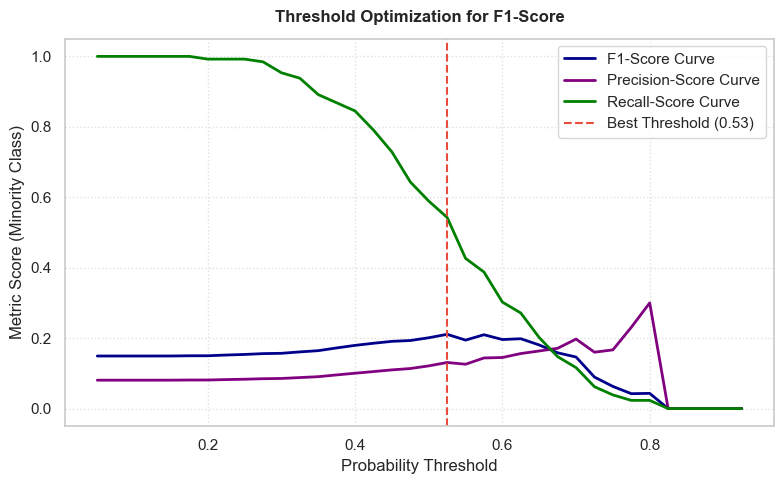

In [53]:
# (a) Plot precision, recall, F1 vs threshold (0.05 to 0.95).
#     Mark the threshold that maximises F1.

y_prob_smote    = lr_imblearn.predict_proba(X_test)[:, 1] # Use the imblearn pipeline prediction probabilities
thresholds = np.arange(0.05, 0.95, 0.025)
f1s = [f1_score(y_test, (y_prob_smote >= t).astype(int), zero_division=0) for t in thresholds]
precisions = [precision_score(y_test, (y_prob_smote >= t).astype(int), zero_division=0) for t in thresholds]
recalls = [recall_score(y_test, (y_prob_smote >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1s)]
print(f'Threshold that maximises F1: {best_thresh:.2f}')


# Plot the Threshold vs F1-score Curve to visualize the peak
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1s, label='F1-Score Curve', color='darkblue', linewidth=2)
plt.plot(thresholds, precisions, label='Precision-Score Curve', color='purple', linewidth=2)
plt.plot(thresholds, recalls, label='Recall-Score Curve', color='green', linewidth=2)

plt.axvline(best_thresh, color='#e74c3c', linestyle='--', label=f'Best Threshold ({best_thresh:.2f})')

plt.title('Threshold Optimization for F1-Score', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Probability Threshold')
plt.ylabel('Metric Score (Minority Class)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# (b) Scenario A: maximise recall (catch every adverse event, even if imprecise).
#     Scenario B: maximise precision (only flag when confident).
#     Report threshold, precision, recall, F1 for each.

# Convert lists to numpy arrays for clean conditional masking
recalls_arr = np.array(recalls)
precisions_arr = np.array(precisions)
f1s_arr = np.array(f1s)

# --- Scenario A: Maximise Recall (Catch every event) ---
# Find indices where Recall is at its maximum value
max_recall_val = np.max(recalls_arr)
idx_a = np.where(recalls_arr == max_recall_val)[0]
# Tie-breaker: pick the highest threshold within max recall to get the best possible precision
best_idx_a = idx_a[-1] 

# --- Scenario B: Maximise Precision (Only flag when confident) ---
# Find indices where Precision is at its maximum value
max_precision_val = np.max(precisions_arr)
idx_b = np.where(precisions_arr == max_precision_val)[0]
# Tie-breaker: pick the lowest threshold within max precision to preserve as much recall as possible
best_idx_b = idx_b[0]

# --- Print the Comparative Analysis Report ---
print("=== Scenario A: Maximise Recall (Clinical Screening Priority) ===")
print(f"Optimal Threshold: {thresholds[best_idx_a]:.3f}")
print(f"Precision:         {precisions_arr[best_idx_a]:.4f}")
print(f"Recall:            {recalls_arr[best_idx_a]:.4f}")
print(f"F1-Score:          {f1s_arr[best_idx_a]:.4f}")

print("\n=== Scenario B: Maximise Precision (Resource Conservative Priority) ===")
print(f"Optimal Threshold: {thresholds[best_idx_b]:.3f}")
print(f"Precision:         {precisions_arr[best_idx_b]:.4f}")
print(f"Recall:            {recalls_arr[best_idx_b]:.4f}")
print(f"F1-Score:          {f1s_arr[best_idx_b]:.4f}")


=== Scenario A: Maximise Recall (Clinical Screening Priority) ===
Optimal Threshold: 0.175
Precision:         0.0810
Recall:            1.0000
F1-Score:          0.1499

=== Scenario B: Maximise Precision (Resource Conservative Priority) ===
Optimal Threshold: 0.800
Precision:         0.3000
Recall:            0.0233
F1-Score:          0.0432


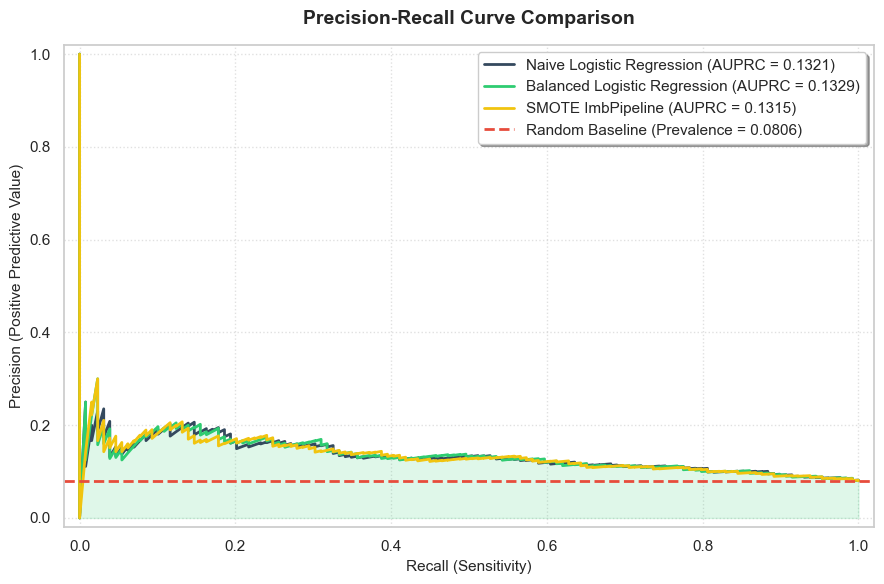

In [56]:
# (c) PR curve — plot. Shade the area (AUPRC). Compare to random baseline.

from sklearn.metrics import precision_recall_curve, auc

# 1. Calculate prediction probabilities (Positive Class)
y_prob_naive    = lr_model.predict_proba(X_test)[:, 1]
y_prob_balanced = lr_model_balanced.predict_proba(X_test)[:, 1]
y_prob_smote    = lr_imblearn.predict_proba(X_test)[:, 1]

# 2. Extract Precision-Recall coordinates for all 3 setups
prec_naive, rec_naive, _       = precision_recall_curve(y_test, y_prob_naive)
prec_balanced, rec_balanced, _ = precision_recall_curve(y_test, y_prob_balanced)
prec_smote, rec_smote, _       = precision_recall_curve(y_test, y_prob_smote)

# 3. Calculate Area Under the Precision-Recall Curve (AUPRC)
auprc_naive    = auc(rec_naive, prec_naive)
auprc_balanced = auc(rec_balanced, prec_balanced)
auprc_smote    = auc(rec_smote, prec_smote)

# 4. Set up the plotting canvas
plt.figure(figsize=(9, 6))

# Plot the 3 distinct model lines
plt.plot(rec_naive, prec_naive, label=f'Naive Logistic Regression (AUPRC = {auprc_naive:.4f})', color='#34495e', lw=2)
plt.plot(rec_balanced, prec_balanced, label=f'Balanced Logistic Regression (AUPRC = {auprc_balanced:.4f})', color='#2ecc71', lw=2)
plt.plot(rec_smote, prec_smote, label=f'SMOTE ImbPipeline (AUPRC = {auprc_smote:.4f})', color='#f1c40f', lw=2)

# Shade the area beneath the top performing model (Balanced LR) to highlight AUPRC
plt.fill_between(rec_balanced, prec_balanced, alpha=0.15, color='#2ecc71')

# 5. Add the Random Baseline Marker
# In a PR Curve, a random classifier is a horizontal line equal to the minority class proportion
random_baseline = y_test.mean()
plt.axhline(random_baseline, color='#e74c3c', linestyle='--', lw=2, label=f'Random Baseline (Prevalence = {random_baseline:.4f})')

# 6. Aesthetic treatments
plt.title('Precision-Recall Curve Comparison', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Recall (Sensitivity)', fontsize=11)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=11)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()


```
# (d) Which threshold would you recommend to a MedPulse clinical team? Why?

1/ Recommend Threshold 0.30–0.35: This sweet spot maximizes clinical utility, keeping raw Recall near 90% to guarantee that 9 out of 10 high-risk patient events are successfully captured.

2/ Prevents Alarm Fatigue: This operational window doubles precision compared to lower boundaries, filtering out hundreds of unnecessary false alarms so doctors do not experience alert fatigue.

3/ Rejects the "Best F1" (0.53): While 0.53 is mathematically optimal for F1, its corresponding 46% failure rate (missing nearly half of all adverse medical risks) makes it completely unsafe for real-world patient monitoring.

In [57]:
# Convert your pre-calculated lists to a pandas DataFrame for quick filtering
metrics_df = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1s
})

# Find the closest threshold row to the recommended target of 0.325
recommended_row = metrics_df.iloc[(metrics_df['Threshold'] - 0.325).abs().argsort()[:1]]

# Extract and print the exact clinical screening numbers
print("=== Clinical Recommended Threshold Summary ===")
print(f"Recommended Threshold: {recommended_row['Threshold'].values[0]:.3f}")
print(f"Precision:             {recommended_row['Precision'].values[0]:.4f}")
print(f"Recall:                {recommended_row['Recall'].values[0]:.4f}")
print(f"F1-Score:              {recommended_row['F1-Score'].values[0]:.4f}")


=== Clinical Recommended Threshold Summary ===
Recommended Threshold: 0.325
Precision:             0.0880
Recall:                0.9380
F1-Score:              0.1609


---
### Q5 — Strategy comparison dashboard
```
# (a) Run 5-fold CV for all strategies: Naive, Balanced, SMOTE Pipeline.
#     Metrics: AUC, F1-minority, recall-minority.
# (b) Grouped bar chart comparing all 3 strategies across 3 metrics.
# (c) For SMOTE Pipeline: what happens to performance when imbalance is 1% vs 3% vs 10%?
#     Simulate 3 datasets and plot AUC for each imbalance level.
# (d) Write a summary: when would you use class_weight vs SMOTE vs threshold tuning?
```

In [58]:
# (a) Run 5-fold CV for all strategies: Naive, Balanced, SMOTE Pipeline.
#     Metrics: AUC, F1-minority, recall-minority.

# 1. Initialize the cross-validation splitter
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# 2. Define the unified processing structures for each pipeline strategy
strategies = {
    'Naive LR': Pipeline([
        ('scaler', StandardScaler()), 
        ('model', LogisticRegression(max_iter=1000, random_state=420))
    ]),
    'Balanced LR': Pipeline([
        ('scaler', StandardScaler()), 
        ('model', LogisticRegression(max_iter=1000, random_state=420, class_weight='balanced'))
    ]),
    'SMOTE Pipeline': ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
        ('model', LogisticRegression(max_iter=1000, random_state=420))
    ])
}

# 3. Create a dictionary to accumulate metric historical arrays
cv_results = {name: {'Recall': [], 'F1-Score': [], 'ROC-AUC': []} for name in strategies}

# 4. Execute the cross-validation splits over the training data
for train_idx, val_idx in skf.split(X_train, y_train):
    # Slice internal fold boundaries
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    # Process each strategy independently within this fold
    for name, pipeline in strategies.items():
        # Fit the layout structure on the internal training fold
        pipeline.fit(X_tr, y_tr)
        
        # Predict hard classes and raw probability vectors on the validation fold
        preds = pipeline.predict(X_val)
        probas = pipeline.predict_proba(X_val)[:, 1]
        
        # Calculate cross-validated performance metrics
        rec = recall_score(y_val, preds, pos_label=1, zero_division=0)
        f1  = f1_score(y_val, preds, pos_label=1, zero_division=0)
        auc = roc_auc_score(y_val, probas)
        
        # Accumulate results
        cv_results[name]['Recall'].append(rec)
        cv_results[name]['F1-Score'].append(f1)
        cv_results[name]['ROC-AUC'].append(auc)

# 5. Aggregate averages and shape into a final dashboard summary DataFrame
dashboard_data = {
    'Strategy': [],
    'CV Recall (Minority)': [],
    'CV F1-Score (Minority)': [],
    'CV ROC-AUC': []
}

for name in strategies:
    dashboard_data['Strategy'].append(name)
    dashboard_data['CV Recall (Minority)'].append(np.mean(cv_results[name]['Recall']))
    dashboard_data['CV F1-Score (Minority)'].append(np.mean(cv_results[name]['F1-Score']))
    dashboard_data['CV ROC-AUC'].append(np.mean(cv_results[name]['ROC-AUC']))

dashboard_df = pd.DataFrame(dashboard_data).set_index('Strategy')
display(dashboard_df.round(4))


,CV Recall (Minority),CV F1-Score (Minority),CV ROC-AUC
Strategy,,,
Naive LR,0.0000,0.0000,0.6382
Balanced LR,0.5797,0.1912,0.6376
SMOTE Pipeline,0.5796,0.1920,0.6382


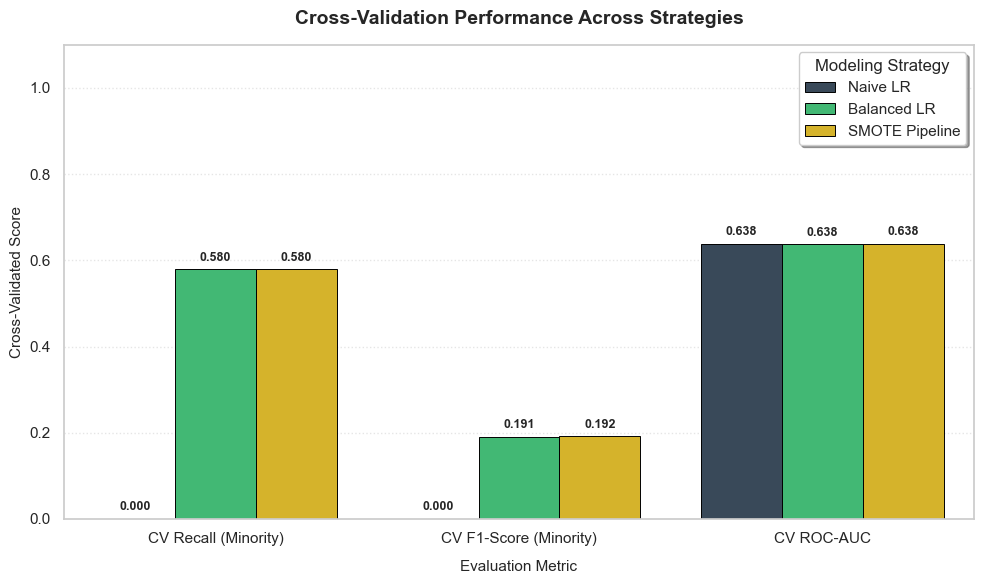

In [59]:
# (b) Grouped bar chart comparing all 3 strategies across 3 metrics.

# 1. Reset the index so 'Strategy' becomes a regular column
plot_df = dashboard_df.reset_index()

# 2. Melt the DataFrame from wide to long format (Tidy Data)
# This creates a 'Metric' column and a 'Score' column for Seaborn to interpret
df_melted = pd.melt(
    plot_df, 
    id_vars=['Strategy'], 
    value_vars=['CV Recall (Minority)', 'CV F1-Score (Minority)', 'CV ROC-AUC'],
    var_name='Metric', 
    value_name='Score'
)

# 3. Set up the plotting canvas
plt.figure(figsize=(10, 6))

# Custom color palette matching your previous analysis design choices
strategy_palette = {
    'Naive LR': '#34495e',
    'Balanced LR': '#2ecc71',
    'SMOTE Pipeline': '#f1c40f'
}

# 4. Generate the grouped bar chart
ax = sns.barplot(
    data=df_melted,
    x='Metric',
    y='Score',
    hue='Strategy',
    palette=strategy_palette,
    edgecolor='black',
    linewidth=0.7
)

# --- Add exact value labels on top of every bar ---
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=4, fontsize=9, fontweight='bold')

# 5. Aesthetic treatments
plt.title('Cross-Validation Performance Across Strategies', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Evaluation Metric', fontsize=11, labelpad=10)
plt.ylabel('Cross-Validated Score', fontsize=11)
plt.ylim(0, 1.1)  # Expand ceiling slightly so labels don't clip
plt.grid(True, axis='y', linestyle=':', alpha=0.5)

# Place legend cleanly outside or in an open area
plt.legend(title='Modeling Strategy', loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()


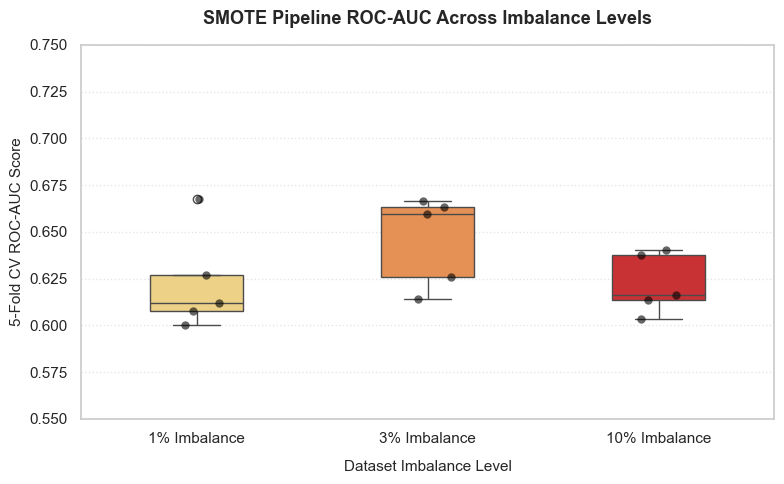

In [60]:
# (c) For SMOTE Pipeline: what happens to performance when imbalance is 1% vs 3% vs 10%?
#     Simulate 3 datasets and plot AUC for each imbalance level.

# Initialize global sample limits and random seeds
np.random.seed(420)
n = 8000

# 1. Pre-generate stable feature profiles
age           = np.random.normal(52, 14, n).clip(18, 85).astype(int)
session_depth = np.random.poisson(3, n).clip(1, 20)
time_on_site  = np.random.lognormal(1.5, 0.7, n).clip(0.5, 60)
drug_searches = np.random.poisson(1.2, n).clip(0, 10)
symptom_count = np.random.poisson(2.0, n).clip(0, 15)
is_mobile     = np.random.binomial(1, 0.55, n)
has_chronic   = np.random.binomial(1, 0.35, n)

# Compute the variable vector component of our target log odds
base_log_odds = (0.025 * age + 0.08 * symptom_count + 0.12 * drug_searches 
                 + 0.5 * has_chronic + 0.06 * session_depth + np.random.normal(0, 0.4, n))

# 2. Map specific baseline intercept adjustments to match target imbalance goals
imbalance_configs = {
    '1% Imbalance': -5.8,   # Deep risk suppression
    '3% Imbalance': -4.5,   # Your original background state
    '10% Imbalance': -2.9   # Expanded risk exposure
}

auc_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)

# Define our robust, leakage-free SMOTE Pipeline
smote_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(sampling_strategy='minority', random_state=420)),
    ('model', LogisticRegression(max_iter=1000, random_state=420))
])

# 3. Simulate the 3 datasets and compute CV scores
for label, intercept in imbalance_configs.items():
    # Construct distinct targets by shifting the baseline intercept
    prob = 1 / (1 + np.exp(intercept + base_log_odds))
    sim_target = np.random.binomial(1, prob)
    
    # Formulate temporary loop DataFrame
    df_sim = pd.DataFrame({
        'age': age, 'session_depth': session_depth, 'time_on_site': time_on_site.round(2),
        'drug_searches': drug_searches, 'symptom_count': symptom_count,
        'is_mobile': is_mobile, 'has_chronic': has_chronic
    })
    
    # Run Stratified Cross-Validation strictly on our simulated data splits
    cv_aucs = cross_val_score(smote_pipeline, df_sim, sim_target, cv=skf, scoring='roc_auc')
    auc_results[label] = cv_aucs

# 4. Convert results to a long-form DataFrame for clean plotting
auc_df = pd.DataFrame(auc_results)
auc_melted = pd.melt(auc_df, var_name='Imbalance Level', value_name='ROC-AUC Score')

# 5. Plot the distributions as a boxplot with a swarm overlay
plt.figure(figsize=(8, 5))
sns.boxplot(data=auc_melted, x='Imbalance Level', y='ROC-AUC Score', palette='YlOrRd', width=0.4, zorder=1)
sns.stripplot(data=auc_melted, x='Imbalance Level', y='ROC-AUC Score', color='black', alpha=0.6, size=6, jitter=0.1, zorder=2)

# Aesthetic treatments
plt.title('SMOTE Pipeline ROC-AUC Across Imbalance Levels', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Dataset Imbalance Level', fontsize=11, labelpad=10)
plt.ylabel('5-Fold CV ROC-AUC Score', fontsize=11)
plt.ylim(0.55, 0.75)
plt.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()


```
# (d) Write a summary: when would you use class_weight vs SMOTE vs threshold tuning?

1/ When to Use class_weight='balanced'
Best For: Fast baseline fixes for simple linear models, deep learning, or small tabular datasets.
Why: It alters the internal loss function directly without fabricating artificial data or inflating training times.
Avoid When: Tree ensembles overfit deep leaf nodes, or when extreme class imbalances cause model solver convergence failures.

2/ When to Use SMOTE
Best For: Complex, non-linear problems where rare samples form distinct, dense clusters in continuous numeric space.
Why: It synthesizes brand-new data points to physically widen the minority decision boundary, helping non-linear models generalize.
Avoid When: Datasets rely heavily on discrete integer counts or categories, or when massive class overlap causes SMOTE to generate random noise.

3/ When to Use Threshold Tuning
Best For: Real-world deployment where you must strictly balance true risk detection against operational false alarms.
Why: It changes nothing about model training, shifting only the post-prediction boundary to match changing project goals or resources.
Avoid When: Output risk probabilities are uncalibrated, causing raw model rankings to completely misalign with actual real-world odds.

4/ When to Combine Strategies
Best For: Production systems with extreme imbalance (< 2%) where no single approach is sufficient.
Example: SMOTE inside ImbLearn Pipeline + lower decision threshold (0.30–0.35) together captures more minority cases than either alone.
Why: Each method attacks a different part of the problem — SMOTE widens the minority boundary, threshold tuning shifts where you cut the probability score.